# 📈 Pairs Trading — Empirical Methods in Finance
---
**Project 1** | Hotel Industry Stocks | 2010–2025

> **Objective:** Identify cointegrated pairs of stocks in the hotel sector and exploit the mean-reverting behaviour of their spread for a pairs trading strategy.

---

## 📥 Step 1 — Download Data of Interest

We will use data downloaded from **yfinance**. The data we download is from the **Hotel industry**. We download 5 different stocks for this project:

| Ticker | Company |
|--------|---------|
| `BKNG` | Booking Holdings |
| `H` | Hyatt Hotels |
| `HLT` | Hilton Worldwide |
| `MAR` | Marriott International |
| `IHG` | InterContinental Hotels Group |

In [1]:
# --- Imports ---
from main import Fetch_Data
from main import Select_Pair
from main import Fetch_wrds
from main import Simple_Pair_Trading
from main import Rolling_Pair_Trading
from main import Rolling_Pair_Trading_coint_filter
import matplotlib.pyplot as plt
import numpy as np
from utils import plot_n_series, plot_wealth_positions_spread
import pandas as pd


In [2]:
start_date = '2010-01-01'
end_date = '2025-01-01'
tickers = ['IHG', 'HLT', 'MAR', 'BKNG', 'H']

In [3]:
# --- Download & log-transform prices ---
fetcher = Fetch_Data(start_date, end_date, tickers)
data_raw   = fetcher.download_data()

/Users/mpecaut/Empirical-Methods-In-Finance/Project1/main.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(self.tickers, start = self.start_date, end = self.end_date)
[*********************100%***********************]  5 of 5 completed


In [4]:
data_raw

Ticker,BKNG,H,HLT,IHG,MAR
Date,,,,,
2010-01-04,219.852890,28.976202,NaN,12.650039,21.998898
2010-01-05,222.405197,29.014891,NaN,12.562920,22.126287
2010-01-06,215.062378,28.744083,NaN,12.510645,22.189983
2010-01-07,212.166504,28.908501,NaN,12.641332,22.277565
2010-01-08,212.245041,28.734413,NaN,12.885270,22.325340
...,...,...,...,...,...
2024-12-24,5073.581543,157.784744,252.564163,123.299652,283.074371
2024-12-26,5046.941406,158.670151,251.068268,123.426201,283.242401
2024-12-27,4988.856445,157.645462,249.253281,123.007584,280.376007


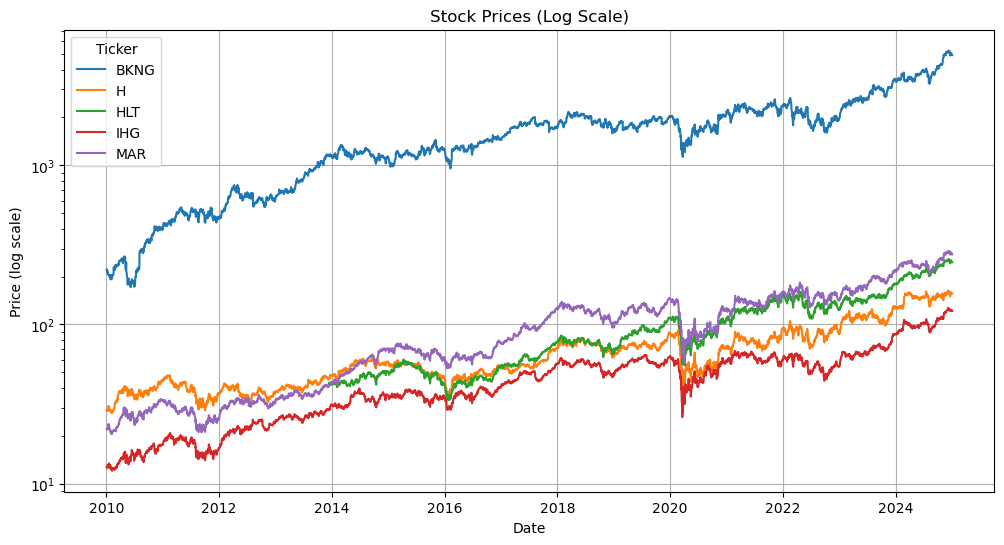

In [5]:
plot_n_series(data_raw,'Stock Prices (Log Scale)','log', 'Date', 'Price (log scale)')

---
## 📊 Step 2 — Stationarity & Cointegration

**Stationarity** means that a serie's two first moments are constant through time along with time-independent autocovariance (covariance of a time series with itself only depends on the lag). This implies that the series does not exhibit any trend or seasonal effect ; it constantly reverts to its mean.

---

It is important to differentiate **cointegration** from **correlation**. Two assets are correlated in the sense that if one moves up, the other will certainly also move up by some amount. Mathematically speaking, correlation measures the short-term linear relationship between two time series. However, this might not imply that the spread between those 2 assets is constant. Indeed, it might even diverge. This is where cointegration comes into play. If two assets are cointegrated, then the spread (the price difference between the 2 assets) will remain constant through time (spread is therefore stationary). This implies that if the spread diverges (goes above or below its normal level), in theory, it should not be long before this value comes back to its average level. This is what we will exploit later on.

For some little more theory, cointegration describes the long-term relationship between two non-stationary time series. While the individual serie might drift (non-stationarity condition), a specific linear combination of them stays near a constant mean.

---

#### 🔬 What does `statsmodels.tsa.stattools.coint` do?

**Step 1 — Regress the two time series.**  
For example, if the first time series is Booking log price and the second one is IHG log price:

$$Booking_t = \alpha + \beta \cdot IHG_t + \epsilon_t$$

| Parameter | Interpretation |
|-----------|---------------|
| $\alpha$ | Price level difference between the two stocks. Since Booking trades at log price ≈ 6–8 and IHG ≈ 2.5–5.5, we expect $\alpha \approx 3$ |
| $\beta$ | How much of Booking's price is explained by IHG — analogous to the CAPM beta. If $\beta = 0.3$, a 1% drop in IHG implies a 0.3% drop in Booking |
| $\epsilon$ | The residual — the part of Booking's price *unexplained* by IHG, capturing the random deviation from the long-run relationship |

**Step 2 — Extract the residuals** and test them for stationarity using an ADF test. If the residuals are stationary, the pair is cointegrated.

In [6]:
data = np.log(data_raw)

In [7]:
# --- Run cointegration test on all permutations ---
pairselect = Select_Pair(data)
permut     = pairselect.permutations()
most_coint_pair, data_most_coint_pair = pairselect.are_cointegrated()

 Most cointegrated pair: BKNG — IHG


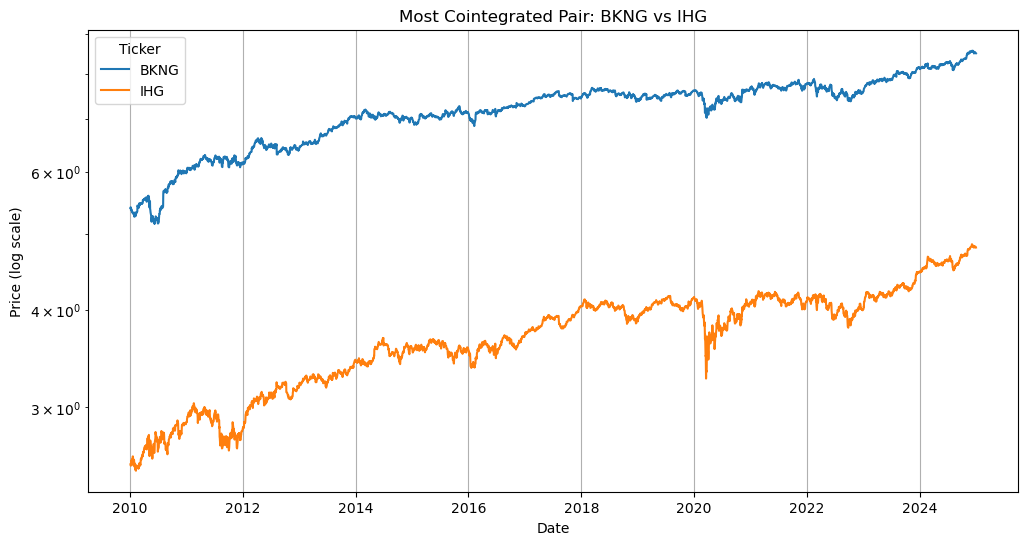

In [8]:
# --- Plot the most cointegrated pair ---
print(f' Most cointegrated pair: {most_coint_pair[0]} — {most_coint_pair[1]}')
plot_n_series(data_most_coint_pair, f'Most Cointegrated Pair: {most_coint_pair[0]} vs {most_coint_pair[1]}', 'log', 'Date', 'Price (log scale)')

### Extract the values alpha,beta and the spread

In [9]:
tickers = [data_most_coint_pair.columns[0],data_most_coint_pair.columns[1]]

alpha,beta,residuals = pairselect.extract_ratios_cointegrated_pair(data_most_coint_pair,tickers)


In [10]:
std_residuals = pairselect.normalize_residuals(residuals)

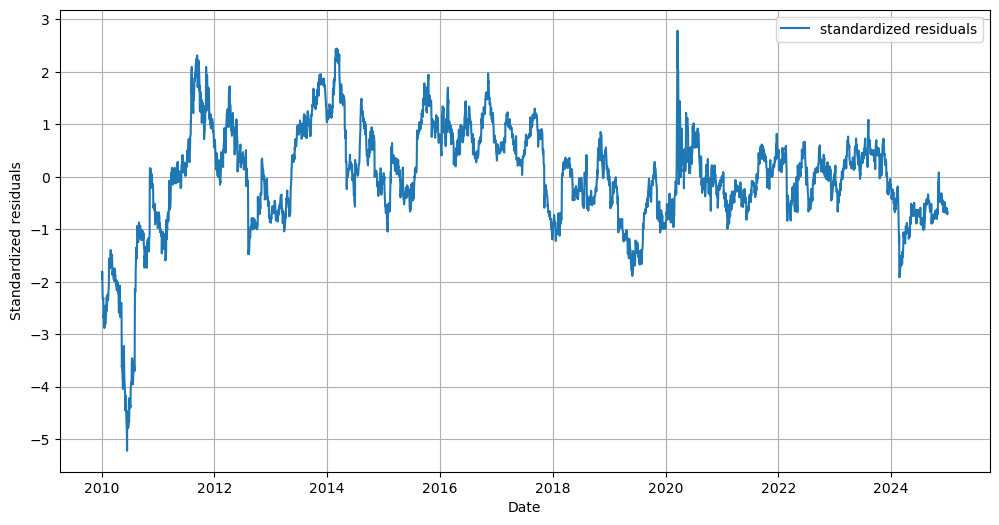

In [11]:
plt.figure(figsize= (12,6))
plt.plot(std_residuals, label = 'standardized residuals')
plt.grid()
plt.xlabel('Date')
plt.ylabel('Standardized residuals')
plt.legend()
plt.show()


---

## 📈 Step 3 — Pair Trading


Now that we have our pair and we have been able to extract its residual and standardize it, we'll implement a first, simple trading strat based on mean reversion of the spread.

Our regression looks like : $$booking_t = \alpha + \beta IHG_t + \epsilon_t$$ therefore, the normalized spread is : $$z_t = \left( (booking_t - \alpha - \beta IHG_t )- \mu (\epsilon_t) \right) / \sigma(\epsilon_t)$$

We will now incorporate the bid-ask spread as well as some transaction costs. What we will do is to also try to find the optimal threshold (the one leading to the highest sharpe ratio) to enter a trade. I will explain that a little bit below but for now, I will go into WRDS database and fetch crsp bid and ask date for BKNG and IHG

In [12]:
start_date = '2010-01-01'
end_date = '2025-02-01'
tickers = ['IHG','BKNG']
username = 'mariuspecaut'
fetch_wrds = Fetch_wrds(start_date, end_date, tickers, username)

In [13]:
fetch_wrds.create_wrds_connection()
ticker_aliases = {'BKNG': ['BKNG', 'PCLN'],}

bid_ask_spread = fetch_wrds.fetch_bid_ask(ticker_aliases)

Loading library list...
Done


### First, simple trading strat on the whole sample

We have defined the spread as the residual $\varepsilon_t$ which is the part unexplained when regressing asset A on asset B. This spread, which we normalize, should be stationary, it mean-reverts around 0. For visualization purposes, we will test this hypothesis using a Augmented Dickey-Fuller test.

The Null Hypothesis $H_0$ : The time series is not stationary (it has a unique root) ; its mean is not 0. 

In [14]:
p_val,crit_vals = pairselect.test_stationarity()
pairselect.adf_test_results(p_val)

H0 is rejected : the residuals are stationary


In [15]:
threshold = 1.5

In [16]:
simplepairtrading = Simple_Pair_Trading(data_raw,data_most_coint_pair,std_residuals,bid_ask_spread,alpha,beta,threshold)
positions = simplepairtrading.simple_pair_trading()

In [17]:
cumulative_pnl, sharpe_ratio = simplepairtrading.pnl_calculations()

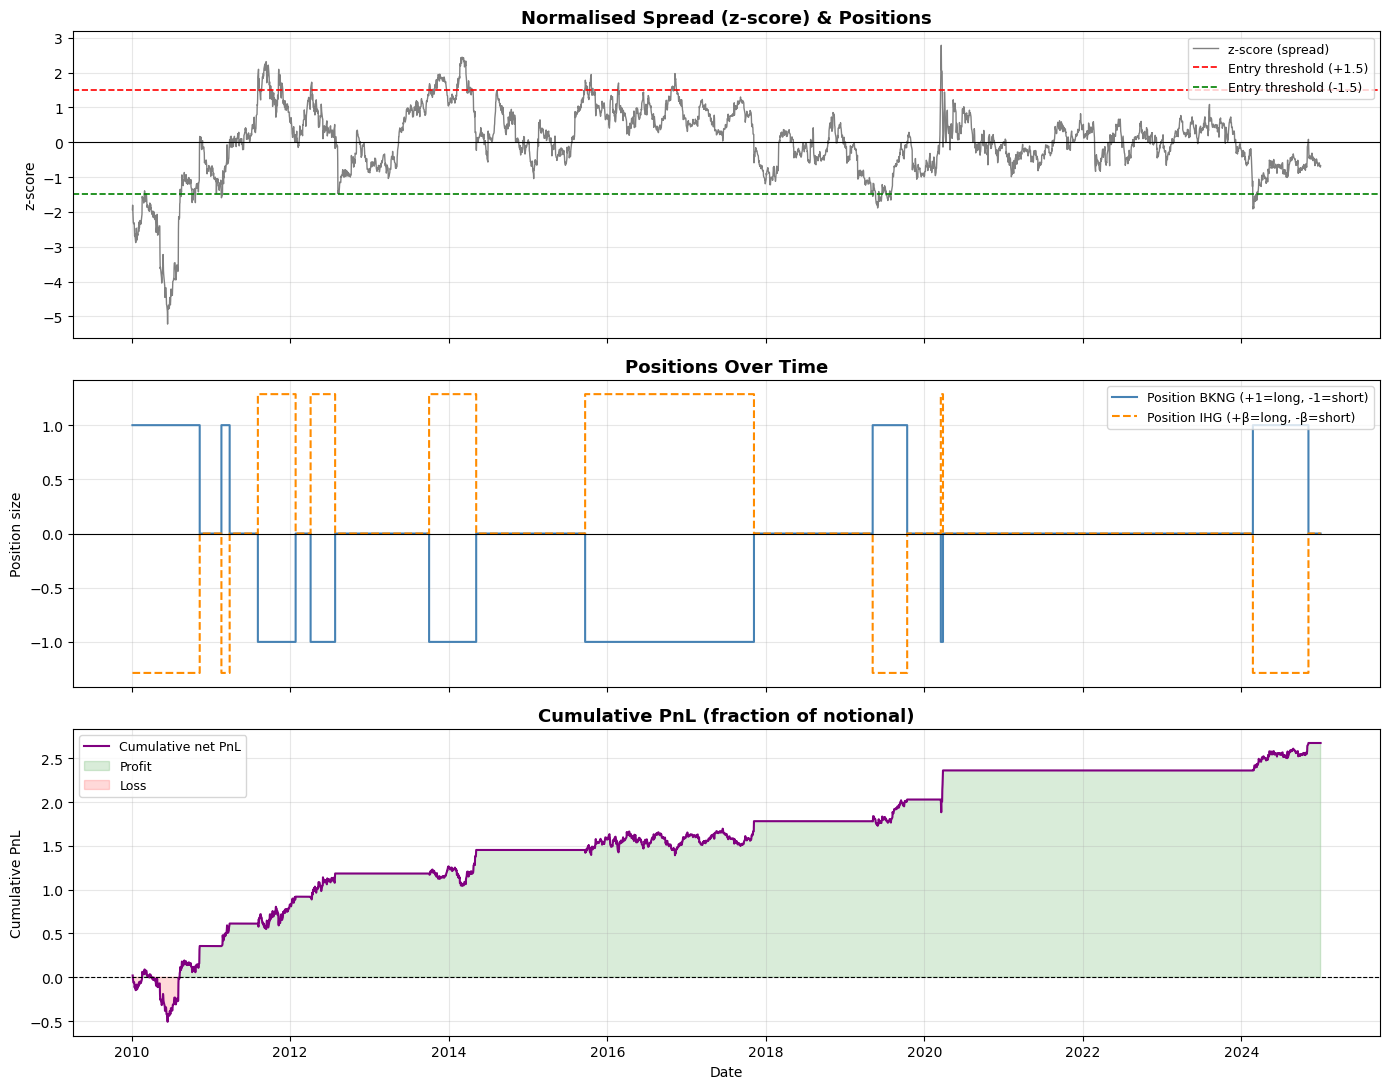

Sharpe ratio (annualised): 0.5648


In [18]:
plot_wealth_positions_spread(data_most_coint_pair, std_residuals, threshold, positions, cumulative_pnl)
print(f"Sharpe ratio (annualised): {sharpe_ratio:.4f}")

---
## Step 5 - Rolling window pair trading strategy 

The previous trading strategy was developed using an estimation of beta based on the whole sample. This is problematic as the position size which is opened at time t depends on beta which depends itself on the whole sample. In practice, this is impossible as we never know what will happen in the future. To overcome this, I will use a rolling window to estimate beta, make decisions and then go forward. 

I will use a rolling windows of 252 days (1 year) to first estimate beta. Then, based on this value, I take decision for tomorrow based on today's spread, where the size I invest in each asset depends on the value of current beta.

In [19]:
window = 252
coint_window = 504

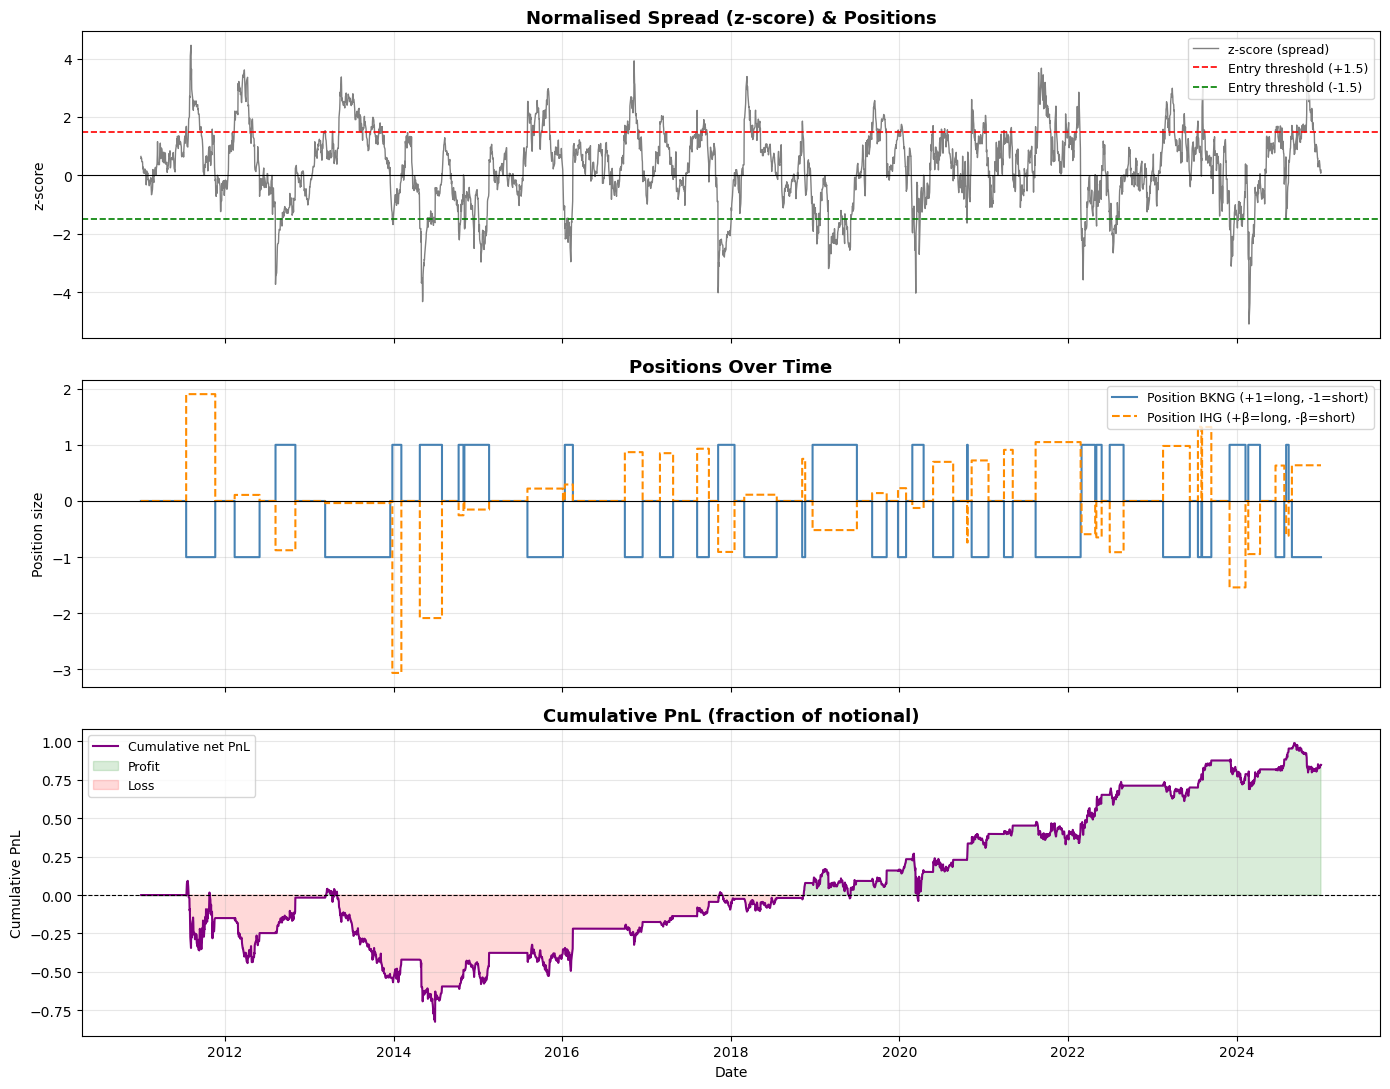

Sharpe ratio (rolling, annualised): 0.0428


In [20]:
rollingpairtrading = Rolling_Pair_Trading(window, coint_window, data_raw,data_most_coint_pair,bid_ask_spread,threshold = 1.5)
rollingpairtrading.extract_rolling_params()
rollingpairtrading.simple_rolling_pair_trading()
cum_pnl, sr =  rollingpairtrading.pnl_calculations()

---
## Step 6 — Rolling Window Strategy with Engle-Granger Cointegration Filter

The previous rolling strategy assumed the pair **remains cointegrated throughout the entire sample**. This may not hold in practice — structural breaks (e.g. COVID, financial crises) or fundamental business changes can cause the long-run relationship to break down temporarily.

**Key idea:** Before generating any signal on day $t$, test whether the pair was still cointegrated over the **last 252 trading days** using the Engle-Granger test:

$$H_0: \text{the residual } \varepsilon_t \text{ is non-stationary (no cointegration)}$$

| p-value | Decision |
|---|---|
| $p < 0.05$ | Reject $H_0$ → cointegration confirmed → **trade normally** |
| $p \geq 0.05$ | Fail to reject $H_0$ → cointegration uncertain → **close any open position and stay flat** |

This adds a regime filter on top of the z-score signal: we only exploit mean-reversion when the statistical foundation (cointegration) is confirmed by the data.


Cointegrated windows : 816 / 3270 (25.0%) → trading allowed
Non-cointegrated     : 2454 (75.0%) → forced flat


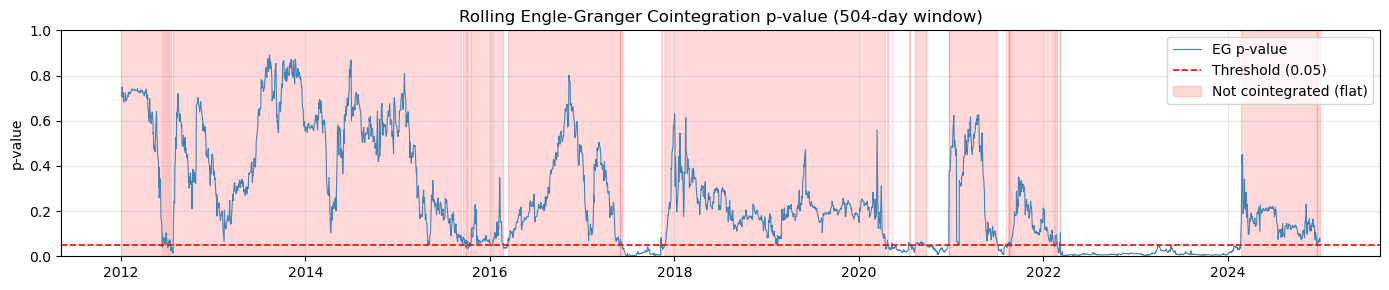

In [21]:
window = 252
coint_window = 504
rollingcointfilter_pairtrading = Rolling_Pair_Trading_coint_filter(0.05,window,coint_window, data_raw,data_most_coint_pair,bid_ask_spread,threshold = 1.5)

rollingcointfilter_pairtrading.extract_cointegration_filter_params()

Cointegrated windows : 816 / 3270 (25.0%) → trading allowed
Non-cointegrated     : 2454 (75.0%) → forced flat


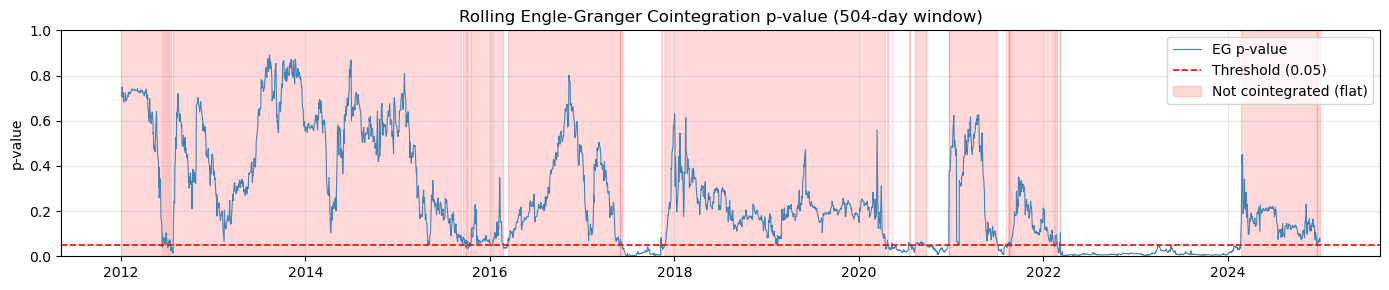

In [22]:
from statsmodels.tsa.stattools import coint as eg_coint
n = len(data_most_coint_pair.iloc[:,0])
ticker_A,ticker_B = data_most_coint_pair.columns
tickers_pair = list([ticker_A,ticker_B])
coint_pvalue_threshold = 0.05   # Significance level for the EG test
window_coint = 504              # 2-year window for cointegration test (longer sample = more test power = fewer false "not cointegrated" rejections)
window_beta  = 252              # 1-year window for alpha/beta/z-score (in order to adapt faster to regime changes)

# Storing : we keep the p-values for every day so that I can plot them
rolling_spread_cf  = pd.Series(np.nan, index=data_most_coint_pair.index)
rolling_beta_cf    = pd.Series(np.nan, index=data_most_coint_pair.index)
rolling_coint_pval = pd.Series(np.nan, index=data_most_coint_pair.index)

# Start at window_coint (the larger window) so both sub-windows always have enough data
for t in range(window_coint, n):
    coint_data = data_most_coint_pair.iloc[t - window_coint : t]  # 504-day window for EG test
    beta_data  = data_most_coint_pair.iloc[t - window_beta  : t]  # 252-day window for OLS

    # 1) Engle-Granger cointegration test on the 504-day window
    _, pval, _ = eg_coint(coint_data[ticker_A], coint_data[ticker_B])
    rolling_coint_pval.iloc[t] = pval

    # 2) estimate alpha, beta, spread on the 252-day window
    selectpair_cf = Select_Pair(beta_data)
    alpha_cf, beta_cf, resid_cf = selectpair_cf.extract_ratios_cointegrated_pair(beta_data, tickers_pair)

    # Out-of-sample spread for day t (yesterday's model applied to today's price)
    spread_t = data_most_coint_pair[ticker_A].iloc[t] - alpha_cf - beta_cf * data_most_coint_pair[ticker_B].iloc[t]
    rolling_spread_cf.iloc[t] = (spread_t - resid_cf.mean()) / resid_cf.std()
    rolling_beta_cf.iloc[t]   = beta_cf

# summary 
rolling_coint_pval_clean = rolling_coint_pval.iloc[window_coint:]
n_total = len(rolling_coint_pval_clean)
n_coint = int((rolling_coint_pval_clean < coint_pvalue_threshold).sum())
pct     = 100 * n_coint / n_total
print(f"Cointegrated windows : {n_coint} / {n_total} ({pct:.1f}%) → trading allowed")
print(f"Non-cointegrated     : {n_total - n_coint} ({100 - pct:.1f}%) → forced flat")

# ── Plot rolling p-value ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(rolling_coint_pval_clean.index, rolling_coint_pval_clean.values,
        lw=0.8, color='steelblue', label='EG p-value')
ax.axhline(coint_pvalue_threshold, color='red', lw=1.2, linestyle='--',
           label=f'Threshold ({coint_pvalue_threshold})')
ax.fill_between(rolling_coint_pval_clean.index, 0, 1,
                where=(rolling_coint_pval_clean >= coint_pvalue_threshold),
                alpha=0.15, color='red', label='Not cointegrated (flat)')
ax.set_ylim(0, 1)
ax.set_ylabel('p-value')
ax.set_title(f'Rolling Engle-Granger Cointegration p-value ({window_coint}-day window)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


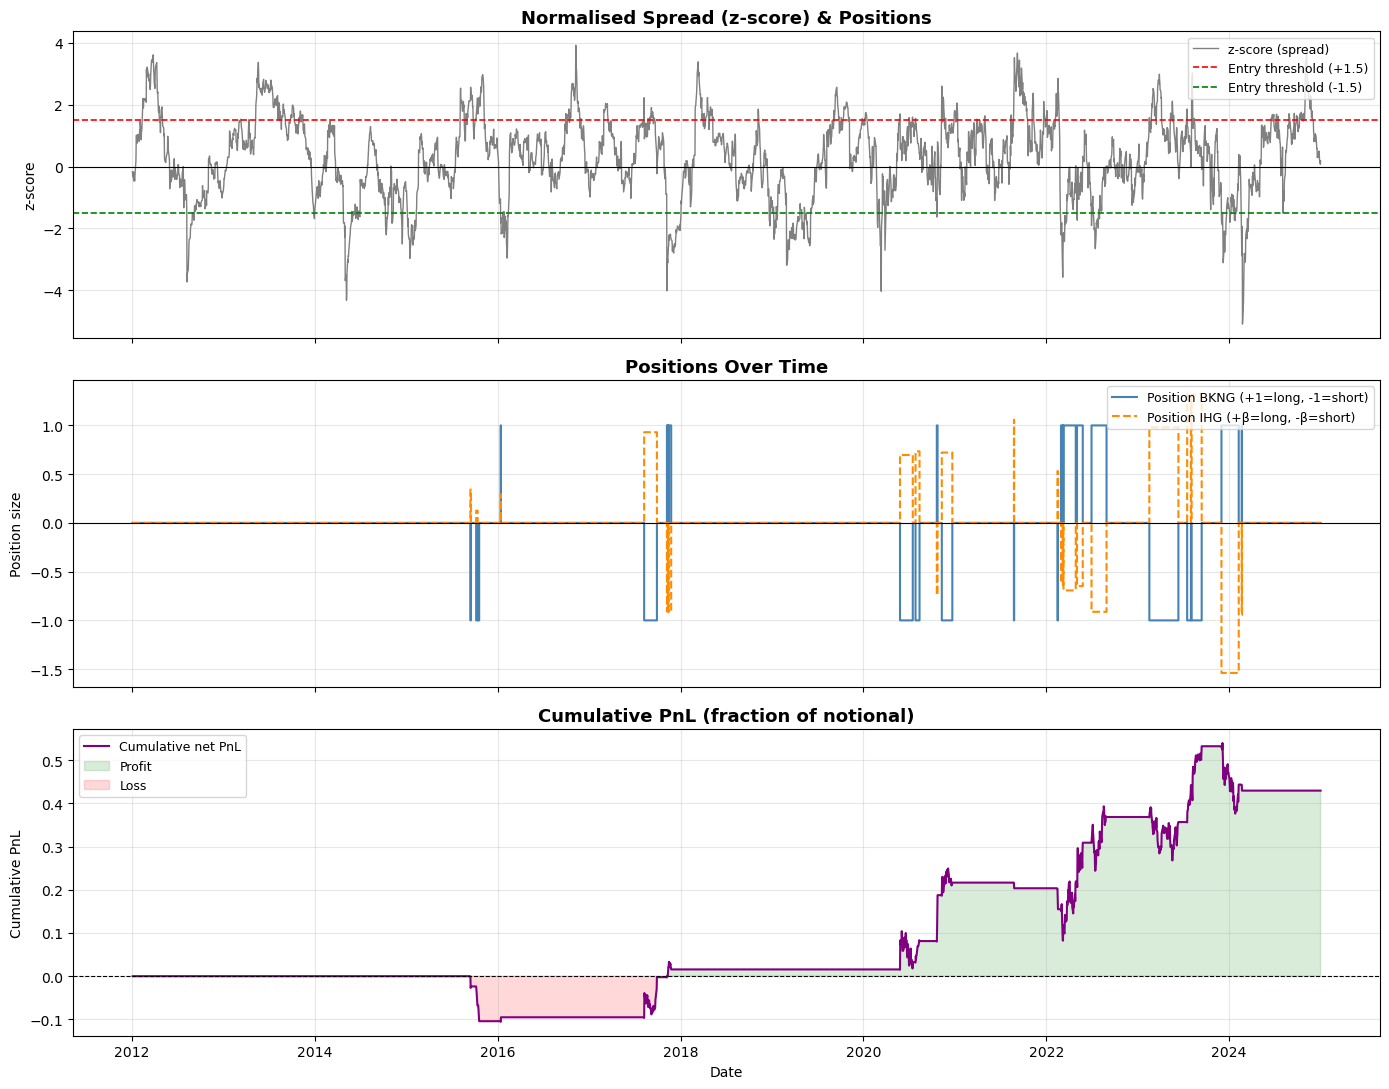

Sharpe ratio (rolling, annualised): -0.1849


In [ ]:
# 
long_A  = False
short_A = False

post_warmup_index = data_most_coint_pair.index[window_coint:] #all rows after the first window which is unsable for trading 
#as we need a first estimate cointegration
n_trading = len(post_warmup_index)

pos_A_cf = np.zeros(n_trading)
pos_B_cf = np.zeros(n_trading)

for i, date in enumerate(post_warmup_index):

    # Carry forward previous day's position
    if i > 0:
        pos_A_cf[i] = pos_A_cf[i-1]
        pos_B_cf[i] = pos_B_cf[i-1]

    # ── Cointegration gate: if p-value ≥ threshold → not cointegrated → close & skip ───
    if rolling_coint_pval.loc[date] >= coint_pvalue_threshold or pd.isna(rolling_coint_pval.loc[date]):
        if long_A or short_A:           # forced exit when relationship breaks down
            pos_A_cf[i] = 0;  pos_B_cf[i] = 0
            long_A = False;   short_A = False
        continue                        # no new signal

    val = rolling_spread_cf.loc[date]
    b   = rolling_beta_cf.loc[date]

    # ── Standard z-score trading logic ──────────────────────────────────────
    if not short_A and not long_A:
        if val >= threshold:            # spread too high → short A, long B
            pos_A_cf[i] = -1;  pos_B_cf[i] =  b;  short_A = True
        elif val <= -threshold:         # spread too low  → long A, short B
            pos_A_cf[i] =  1;  pos_B_cf[i] = -b;  long_A  = True
    elif short_A and val < 0:           # mean-reverted → close
        pos_A_cf[i] = 0;  pos_B_cf[i] = 0;  short_A = False
    elif long_A  and val >= 0:          # mean-reverted → close
        pos_A_cf[i] = 0;  pos_B_cf[i] = 0;  long_A  = False

# ── Build positions DataFrame ─────────────────────────────────────────────
cf_pos_A     = pd.Series(pos_A_cf, index=post_warmup_index, name=ticker_A)
cf_pos_B     = pd.Series(pos_B_cf, index=post_warmup_index, name=ticker_B)
cf_positions = pd.concat([cf_pos_A, cf_pos_B], axis=1)

# ── PnL ───────────────────────────────────────────────────────────────────
cf_price_df   = data_raw[tickers_pair].reindex(post_warmup_index)
cf_returns_df = cf_price_df.pct_change()
cf_spread_df  = bid_ask_spread.reindex(post_warmup_index)

lagged_positions = cf_positions.shift(1).fillna(0)
position_changes = cf_positions.diff().fillna(0)
raw_pnl = lagged_positions.values*cf_returns_df.values

pnl = raw_pnl.sum(axis = 1)

transaction_cost_pct = (cf_spread_df/2)/cf_price_df
transactions_costs = (transaction_cost_pct*np.abs(position_changes.values)).sum(axis=1)


net_pnl = pnl-transactions_costs
cum_pnl = net_pnl.cumsum()

        #Calculating sharpe ratio :
        #Assumption : Rf = 5% --> daily rf = 0.05/252
rf_daily = 0.05/252
excess_pnl = net_pnl - rf_daily

sharpe_ratio = (excess_pnl.mean()/excess_pnl.std())*np.sqrt(252)
        

# Plot using previously coded fct 
plot_wealth_positions_spread(data_most_coint_pair.reindex(rolling_spread_cf.index),rolling_spread_cf, threshold, cf_positions, cum_pnl)
print(f"Sharpe ratio (rolling, annualised): {sharpe_ratio:.4f}")


We can see that rejecting the trading for same cointegration periods leads to overall cumulative returns which are smaller. However, it is clear that the drawdowns are way more limited, reaching approximately $-0.1$, compared to $-0.8$ when allowing to trade regardless of the cointegration regime. This highlights a meaningful risk-adjusted trade-off: filtering trades based on rolling cointegration significantly improves the strategy's resilience to adverse market conditions, even if it comes at the cost of reduced total returns.

---
## Step 7 - Make use of the Kalmann Filter for Dynamic estimates of alpha and beta

### Why a Kalman Filter?

In the rolling OLS approach, $\alpha$ and $\beta$ are estimated on a fixed window of the last $w$ days and then assumed to be constant until the window rolls again. This has three problems:

1. **Arbitrary window**: choosing $w = 252$ is a hyperparameter with no formal justification.
2. **Equal weighting**: observations from 252 days ago carry the same weight as yesterday's — which is economically unreasonable.
3. **Window boundary jumps**: when an extreme observation exits the window, the estimates can jump discontinuously.

The **Kalman filter** solves all three: it processes every new data point one at a time, updates estimates optimally, and exponentially down-weights past observations. The smoothing rate is controlled by a single parameter $\delta$ which has a clear statistical interpretation.

---

### 1 — State-Space Formulation

We model the observation equation as a linear regression whose **coefficients evolve over time**:

$$\underbrace{y_t}_{\text{BKNG}_t} = \underbrace{H_t}_{[1,\ \text{IHG}_t]} \underbrace{\theta_t}_{[\alpha_t,\ \beta_t]^\top} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\, R) \tag{1}$$

The coefficients $\theta_t = [\alpha_t,\ \beta_t]^\top$ are **not fixed** — they are themselves a random process following a **random walk** (transition equation):

$$\theta_t = \theta_{t-1} + \omega_t, \qquad \omega_t \sim \mathcal{N}(0,\, Q) \tag{2}$$

This is the simplest non-trivial dynamic model: the best guess for tomorrow's $\alpha, \beta$ is today's estimate, plus some small random perturbation $\omega_t$ drawn from a zero-mean Gaussian with covariance $Q$.

**Process noise matrix $Q$:** Following Kalman (1960) and as commonly used in financial applications (see Pole, West & Harrison), we set:

$$Q = \frac{\delta}{1 - \delta}\, I_2 \tag{3}$$

$\delta \in (0,1)$ is the single hyperparameter. Small $\delta$ (e.g. $10^{-5}$) means the parameters drift very slowly — appropriate for a stable long-run cointegration relationship. Large $\delta$ (e.g. $10^{-3}$) means parameters can change rapidly.

---

### 2 — The Kalman Filter Recursion

At each time step $t$, the filter maintains two quantities:

- $\hat{\theta}_{t|t}$ : the **posterior mean** of the state (best estimate of $[\alpha_t, \beta_t]^\top$ given data up to $t$)
- $P_{t|t}$ : the **posterior covariance** matrix (uncertainty around that estimate)

The filter alternates between a **Predict** step (propagate forward using the transition equation) and an **Update** step (incorporate the new observation).

#### Step 1 — Predict

Using equation (2), before seeing $y_t$, the best prediction for the state is:

$$\hat{\theta}_{t|t-1} = \hat{\theta}_{t-1|t-1} \tag{4}$$

$$P_{t|t-1} = P_{t-1|t-1} + Q \tag{5}$$

Equation (5) says: **uncertainty grows** between observations because $\theta$ is allowed to drift. Every step adds $Q$ to our uncertainty.

#### Step 2 — Innovation

We compute how much the new observation $y_t$ deviates from what we predicted:

$$e_t = y_t - H_t\, \hat{\theta}_{t|t-1} \tag{6}$$

$$= \text{BKNG}_t - \hat{\alpha}_{t|t-1} - \hat{\beta}_{t|t-1} \cdot \text{IHG}_t$$

This is the **innovation** (or prediction error). It is the raw spread — the deviation of BKNG from its predicted equilibrium value given IHG. We also compute the **innovation variance**:

$$S_t = H_t\, P_{t|t-1}\, H_t^\top + R \tag{7}$$

$S_t$ is a scalar here. It captures both the **estimation uncertainty** of $\theta$ (first term) and the **observation noise** $R$ (second term).

#### Step 3 — Kalman Gain

The Kalman gain $K_t$ is a $2 \times 1$ vector that optimally weights the innovation:

$$K_t = \frac{P_{t|t-1}\, H_t^\top}{S_t} \tag{8}$$

Intuitively: if $P_{t|t-1}$ is large (we are uncertain about $\theta$), $K_t$ is large — we trust the new observation more. If $R$ is large (the observation is noisy), $S_t$ is large and $K_t$ is small — we trust the observation less.

#### Step 4 — Update

We update the state estimate in the direction of the innovation, scaled by the Kalman gain:

$$\hat{\theta}_{t|t} = \hat{\theta}_{t|t-1} + K_t\, e_t \tag{9}$$

And reduce our uncertainty accordingly:

$$P_{t|t} = \left(I - K_t H_t\right) P_{t|t-1} \tag{10}$$

Equation (10) is the **Joseph form** of the covariance update. After incorporating the new data point, $P$ decreases — we know more about $\theta$ than before.

---

### 3 — Why the Filter is Optimal

The Kalman filter is the **minimum variance linear unbiased estimator** (MVLUE) of $\theta_t$ given the observations $y_1, \ldots, y_t$, under the Gaussian assumptions (1)–(2). Formally, it minimises:

$$\mathcal{L}(\hat{\theta}) = \mathbb{E}\left[\|\theta_t - \hat{\theta}_t\|^2\right]$$

among all linear functions of the data. This is exactly what OLS does on the full sample — but the Kalman filter does it **online**, updating at each step in $O(1)$ time rather than refitting from scratch.

---

### 4 — The Normalised Innovation as a Trading Signal

The key insight for pair trading: $e_t \sim \mathcal{N}(0, S_t)$ under the null of no mispricing. So the **normalised innovation**:

$$z_t = \frac{e_t}{\sqrt{S_t}} \tag{11}$$

is already a proper z-score — it is $\mathcal{N}(0,1)$ distributed under the null. No separate rolling window for computing mean and std of residuals is needed. We enter a trade when $|z_t| > \delta_{\text{threshold}}$ and exit when $z_t$ crosses zero, exactly as before.

---

### 5 — Summary of the Full Algorithm

| Step | Equation | Interpretation |
|---|---|---|
| **Predict mean** | $\hat{\theta}_{t\|t-1} = \hat{\theta}_{t-1\|t-1}$ | Best prior guess: no drift in expectation |
| **Predict variance** | $P_{t\|t-1} = P_{t-1\|t-1} + Q$ | Uncertainty grows due to random walk |
| **Innovation** | $e_t = y_t - H_t\hat{\theta}_{t\|t-1}$ | Raw spread = prediction error |
| **Innovation var** | $S_t = H_t P_{t\|t-1} H_t^\top + R$ | Total uncertainty in the observation |
| **Kalman gain** | $K_t = P_{t\|t-1} H_t^\top / S_t$ | How much to trust the new data point |
| **Update mean** | $\hat{\theta}_{t\|t} = \hat{\theta}_{t\|t-1} + K_t e_t$ | Correct estimate with new info |
| **Update variance** | $P_{t\|t} = (I - K_t H_t) P_{t\|t-1}$ | Reduce uncertainty after update |
| **Trading signal** | $z_t = e_t / \sqrt{S_t}$ | Normalised spread ready for threshold rule |

to do : implement optimal threshold (look slides), kalman filter for estimating alpha and beta

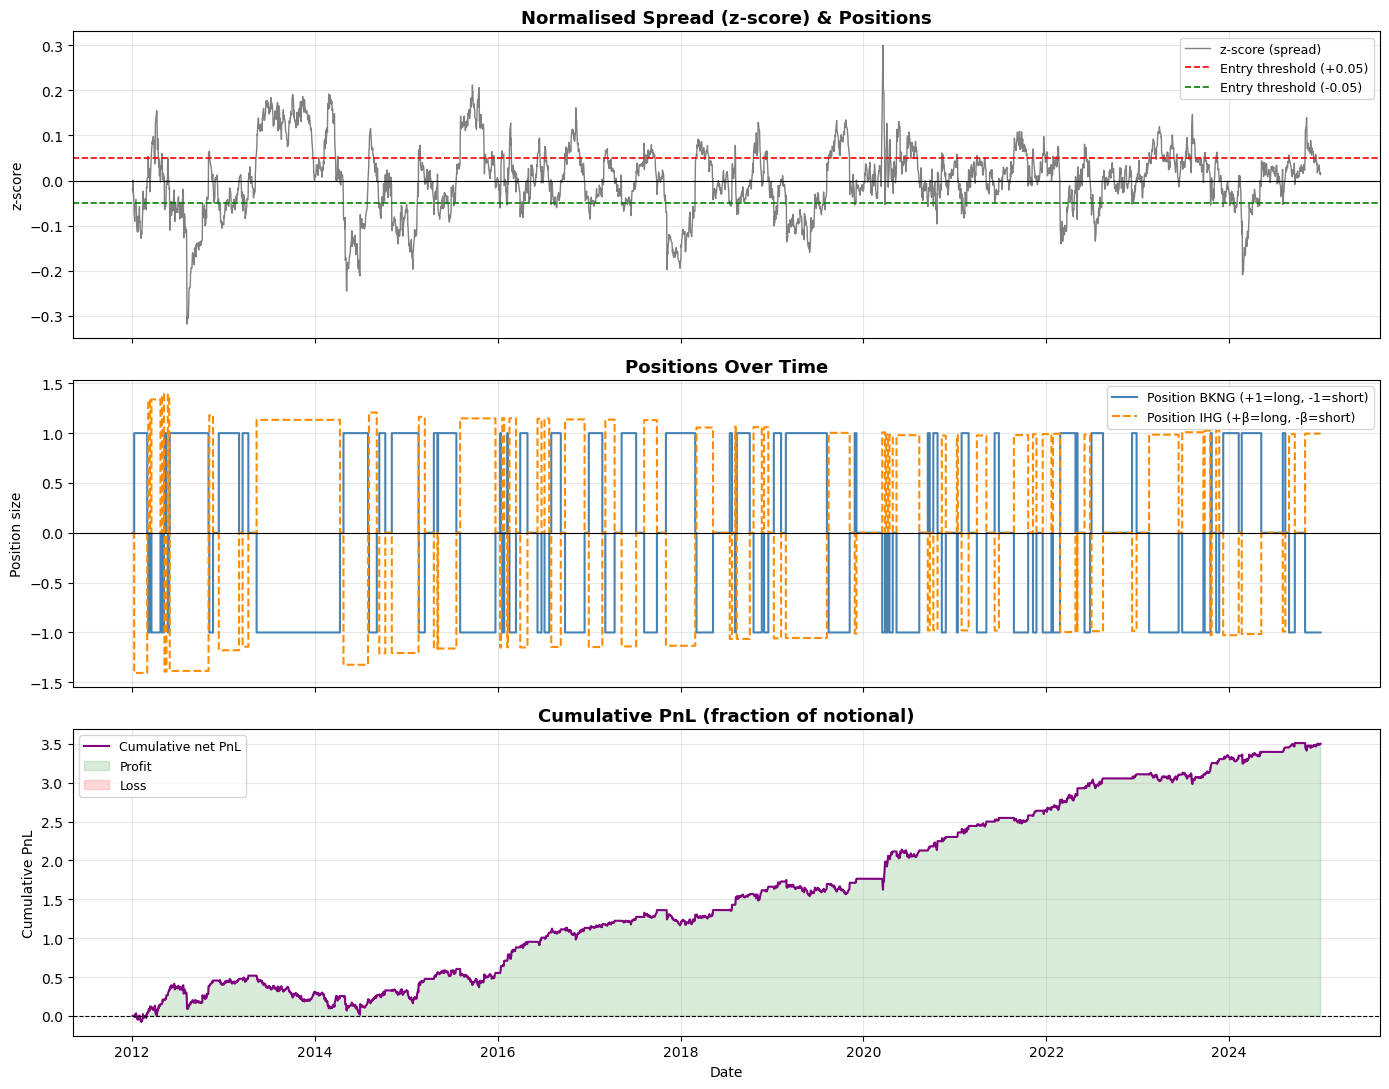

Sharpe ratio (Kalman, annualised): 0.8941


In [54]:
from importlib import reload
import main
reload(main)
from main import Kalman_Pair_Trading

# Instantiate the Kalman pair trader
# delta  : process noise — controls how fast alpha/beta can change (1e-5 → slow/stable)
# R_var  : observation noise variance — set to 1.0 (price-level units, comparable to OLS residual variance)
kf_trader = Kalman_Pair_Trading(
    data_raw           = data_raw,
    most_coint_pair_df = data_most_coint_pair,
    bid_ask_spread     = bid_ask_spread,
    threshold          = 0.05,
    delta              = 1e-5,
    R_var              = 1.0
)

# 1) Run the filter → get time-varying alpha, beta, and the normalised spread
kf_alpha, kf_beta, kf_spread = kf_trader.run_kalman_filter(warmup=504)

# 2) Run the trading loop
kf_trader.kalman_pair_trading()

# 3) PnL + plot
kf_cum_pnl, kf_sharpe = kf_trader.pnl_calculations()

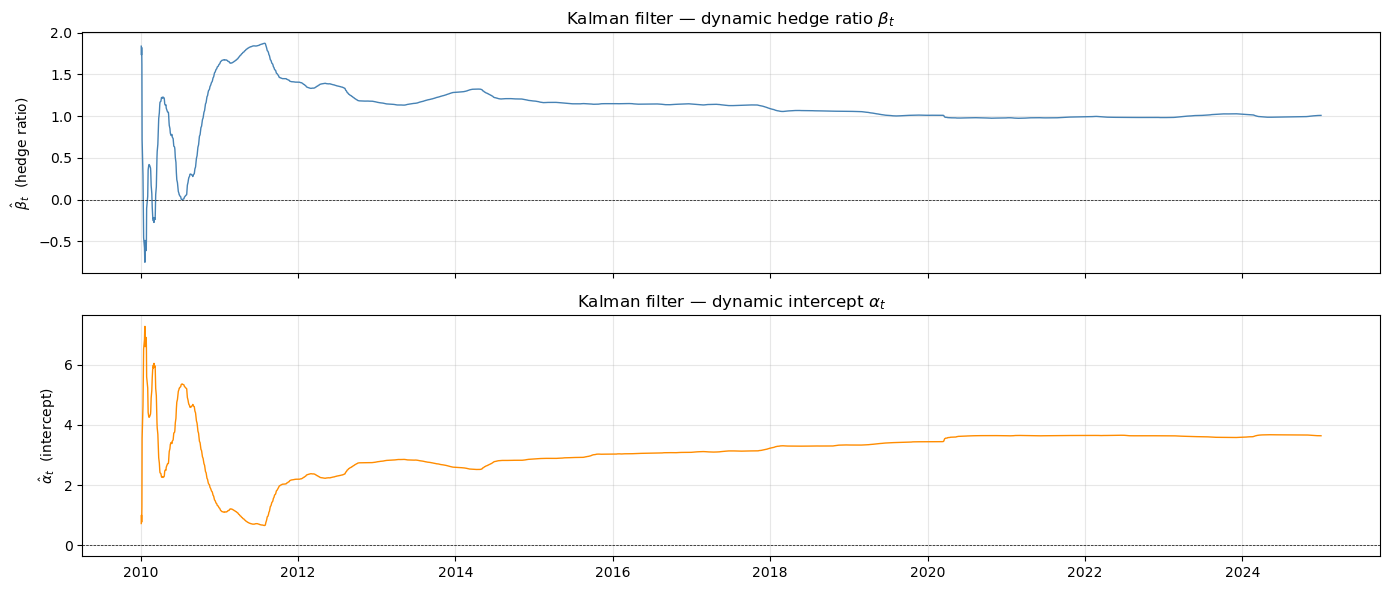

In [45]:
# ── Visualise time-varying alpha and beta estimated by the Kalman filter ─────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(kf_beta, color='steelblue', linewidth=1)
axes[0].set_ylabel(r'$\hat{\beta}_t$  (hedge ratio)')
axes[0].set_title('Kalman filter — dynamic hedge ratio $\\beta_t$')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].grid(True, alpha=0.3)

axes[1].plot(kf_alpha, color='darkorange', linewidth=1)
axes[1].set_ylabel(r'$\hat{\alpha}_t$  (intercept)')
axes[1].set_title('Kalman filter — dynamic intercept $\\alpha_t$')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
*End of Project 1*